# **Boston Housing Data (U.S. Census data)- Statistical Analysis**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [2]:
# Load dataset

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv"
boston_df = pd.read_csv(url)


## **TASK 1 : Familiarize Yourself with the Dataset**

**1. Display the first 5 rows of the dataset.**

In [3]:
# View dataset
boston_df.head(5)

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [4]:
# Drop the 'Unnamed: 0' column
boston_df.drop(columns=['Unnamed: 0'], inplace=True)

**2. Display the data types of each column.**

In [5]:
# Check Datatypes for each columns
boston_df.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,float64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,float64
TAX,float64


**3. Check for missing values in each column.**

In [6]:
# Check null Values
boston_df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


**4. Check for duplicate rows.**

In [7]:
# Check duplicates
boston_df.duplicated().sum()
print("Number of duplicate rows:", boston_df.duplicated().sum())

Number of duplicate rows: 0


**5. Display the correlation matrix of the dataset.**

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


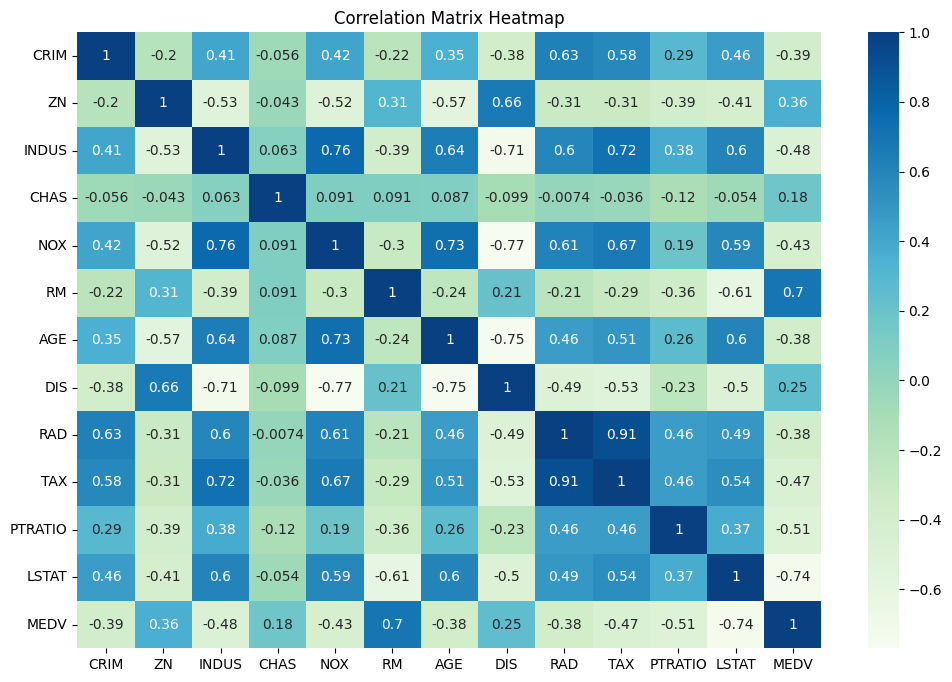

In [8]:
# 1. Display the numerical correlation matrix
correlation_matrix = boston_df.corr()
display(correlation_matrix)

# 2. Display the visual heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='GnBu')
plt.title("Correlation Matrix Heatmap")
plt.show()

## **TASK 2 : Generate Descriptive Statistics and Visualizations**

**1. Display descriptive statistics of the dataset.**

In [9]:
# Descriptive Statistics
boston_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


**2. Create a boxplot for MEDV (Median value of owner-occupied homes).**

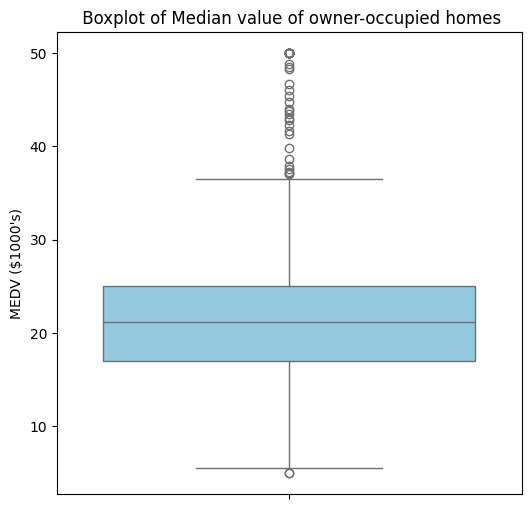

In [10]:
# Create a boxplot for MEDV (Median value of owner-occupied homes).

plt.figure(figsize=(6, 6))
sns.boxplot(y=boston_df['MEDV'], color='skyblue')

# Add titles and labels
plt.title(" Boxplot of Median value of owner-occupied homes")
plt.ylabel("MEDV ($1000's)")

# Display the plot
plt.show()


**Observation:** The median median value of owner-occupied homes is around **$21,000**.

**3. Create a bar plot for CHAS (Charles River dummy variable).**

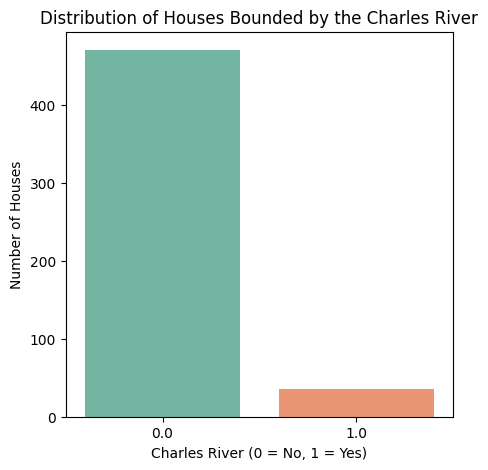

In [11]:
# 1. Prepare the data: Calculate the frequency of each category
chas_counts = boston_df['CHAS'].value_counts().reset_index()
chas_counts.columns = ['CHAS', 'Count']

# 2. Set the figure size
plt.figure(figsize=(5, 5))

# 3. Create the Bar Plot
# We now use 'Count' for the y-axis because barplot needs a numeric value
sns.barplot(x='CHAS', y='Count', data=chas_counts, hue='CHAS', palette='Set2', legend=False)

plt.title("Distribution of Houses Bounded by the Charles River")
plt.xlabel("Charles River (0 = No, 1 = Yes)")
plt.ylabel("Number of Houses")
plt.show()

**Observation :** There are many more houses that **do not border** the Charles River than houses that do border the Charles River.

**4. Discretize AGE into three groups and create a boxplot of MEDV versus these groups:**

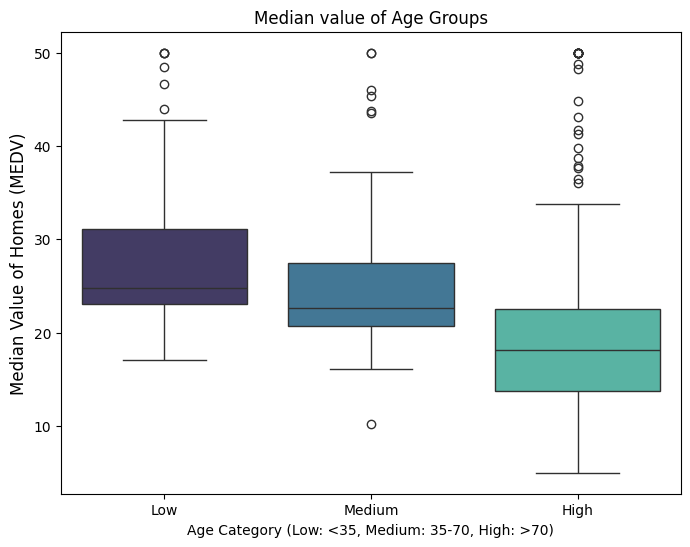

In [12]:
# Discretize AGE into three groups and create a boxplot of MEDV versus these groups:
# Create a boxplot for the MEDV variable vs the AGE variable.
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'],
                        bins=[0, 35, 70, 100],
                        labels=['Low', 'Medium', 'High'])

# Boxplot fo MEDV and Age Group
plt.figure(figsize=(8, 6))
sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df,hue='AGE_GROUP', palette='mako').set_title("Median value of Age Groups")

# Axis Labels
plt.xlabel("Age Category (Low: <35, Medium: 35-70, High: >70)")
plt.ylabel("Median Value of Homes (MEDV)", fontsize=12)
plt.show()

**Observation :** The **older houses are cheaper** compared to the younger houses.

**5. Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres).**

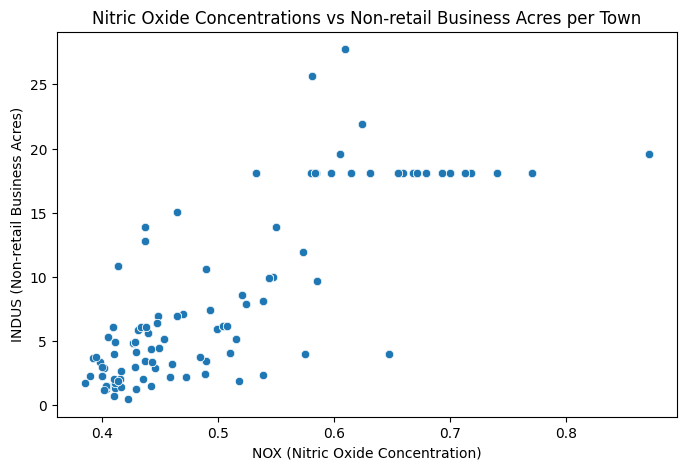

In [13]:
# Create a scatter plot showing the relationship between NOX (nitric oxide concentrations) and INDUS (non-retail business acres).
plt.figure(figsize=(8,5))
sns.scatterplot(x='NOX', y='INDUS', data=boston_df)

plt.title("Nitric Oxide Concentrations vs Non-retail Business Acres per Town")
plt.xlabel("NOX (Nitric Oxide Concentration)")
plt.ylabel("INDUS (Non-retail Business Acres)")
plt.show()

**Observation :** The lower proportion of non-retail business acres per town had **low nitric oxide** concentrations.

**6. Create a histogram for PTRATIO (pupil-teacher ratio).**

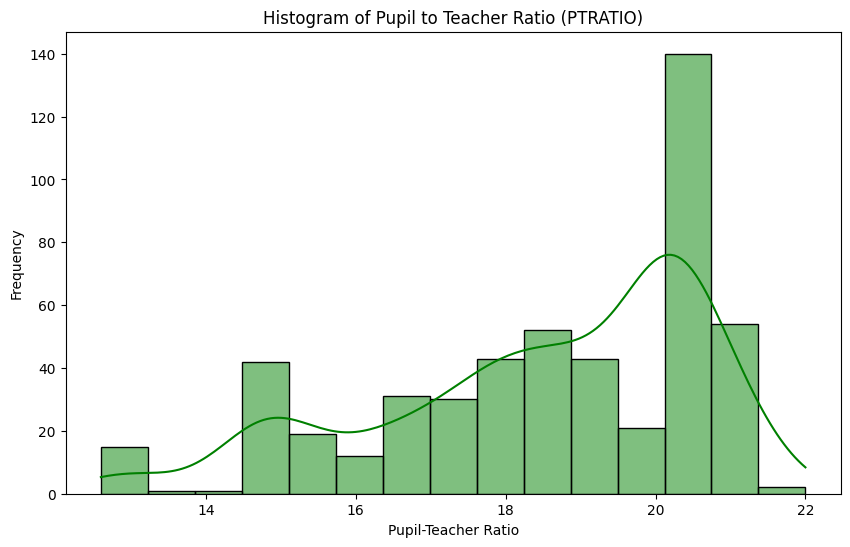

In [14]:
# Create a histogram for PTRATIO (pupil-teacher ratio).

plt.figure(figsize=(10, 6))

# 1. Use 'color' for the bars
# 2. Use 'line_kws' for the KDE line
sns.histplot(boston_df['PTRATIO'], bins=15, kde=True, color='green')

plt.title('Histogram of Pupil to Teacher Ratio (PTRATIO)')
plt.xlabel('Pupil-Teacher Ratio')
plt.ylabel('Frequency')
plt.show()

**Observation :** A majority of the pupil to teacher ratio is **20.2**.

## **TASK 3: Statistical Tests**

**1. Use Levene’s test to check if the variances of MEDV for homes bounded by the Charles River (CHAS = 1) and those not bounded (CHAS = 0) are equal.**

In [15]:
# Levene Test(variance check)

# Levene Test (Variance check for CHAS groups)

# 1. Prepare the data groups
river = boston_df[boston_df['CHAS'] == 1]['MEDV']
no_river = boston_df[boston_df['CHAS'] == 0]['MEDV']

# 2. Perform the Levene's Test
res = stats.levene(river, no_river)

# 3. Display the result
print("LEVENE'S Test Results")
print("-" * 25)
print(f"Statistics : {res.statistic:.4f}")
print(f"P-Value    : {res.pvalue:.4f}")

# 4. Conclusion based on Alpha = 0.05
alpha = 0.05
if res.pvalue < alpha:
    print("\nConclusion: Reject Null Hypothesis (Variances are NOT equal)")
else:
    print("\nConclusion: Fail to Reject Null Hypothesis (Variances are equal)")

LEVENE'S Test Results
-------------------------
Statistics : 4.5903
P-Value    : 0.0326

Conclusion: Reject Null Hypothesis (Variances are NOT equal)


**Interpretation :**

Since the **p-value** ($0.0326$) is less than the significance level of $0.05$, we **reject the null hypothesis**. There is sufficient statistical evidence to conclude that the variance of the Median Value of homes (MEDV) is significantly different between houses bounded by the Charles River and those that are not."

**2. Perform a T-test to determine if there is a significant difference in MEDV between homes bounded and not bounded by the Charles River.**

In [16]:
# Perform T-test (Welch's T-test because Levene's test showed unequal variances)
# Set equal_var=False based on our p-value of 0.0326 from the Levene's test
t_res = stats.ttest_ind(river, no_river, equal_var=False)

print("T-test Results (Welch's T-test)")
print("-" * 30)
print(f"Statistics : {t_res.statistic:.4f}")
print(f"P-Value    : {t_res.pvalue:.4f}")

# Automated conclusion
alpha = 0.05
if t_res.pvalue < alpha:
    print("\nConclusion: Reject Null Hypothesis (Significant difference in MEANS)")
else:
    print("\nConclusion: Fail to Reject Null Hypothesis (No significant difference in MEANS)")

T-test Results (Welch's T-test)
------------------------------
Statistics : 3.1133
P-Value    : 0.0036

Conclusion: Reject Null Hypothesis (Significant difference in MEANS)


**Interpretation :**

**Hypothesis Result:** Since the p-value (0.0036) is less than the significance level ($\alpha = 0.05$),**we reject the null hypothesis**.

**Conclusion:** There is statistically significant evidence to conclude that there is a difference in the median value of houses (MEDV) based on whether they are bounded by the Charles River (CHAS) or not.

**Direction:** Looking at the T-statistic (3.1133), houses near the river generally have a higher median value.

**3. Conduct an ANOVA test to compare MEDV among the three AGE groups created earlier.**

In [17]:
# 1. Separate MEDV into groups based on AGE_GROUP
low = boston_df[boston_df['AGE_GROUP'] == 'Low']['MEDV']
med = boston_df[boston_df['AGE_GROUP'] == 'Medium']['MEDV']
high = boston_df[boston_df['AGE_GROUP'] == 'High']['MEDV']

# 2. Perform the One-Way ANOVA
anova_res = stats.f_oneway(low, med, high)

# 3. Display Results
print("ANOVA Test Results")
print("-" * 25)
print(f"F-Statistic : {anova_res.statistic:.4f}")
print(f"P-Value     : {anova_res.pvalue:.4e}") # Using scientific notation for tiny p-values

# 4. Conclusion
alpha = 0.05
if anova_res.pvalue < alpha:
    print("\nConclusion: Reject Null Hypothesis (Significant difference between age groups)")
else:
    print("\nConclusion: Fail to Reject Null Hypothesis (No significant difference)")

ANOVA Test Results
-------------------------
F-Statistic : 36.4076
P-Value     : 1.7105e-15

Conclusion: Reject Null Hypothesis (Significant difference between age groups)


**Interpretation:**

**Hypothesis Result:** Since the p-value ($1.7105 \times 10^{-15}$) is significantly less than the alpha level of 0.05, **we reject the Null Hypothesis.**

**Conclusion:** There is strong statistical evidence to conclude that there is a significant difference in the median value of houses (MEDV) across the three age groups (Low, Medium, and High).

**Finding:** The age of a property has a measurable impact on its market value. Looking at the earlier boxplots, we can see that newer houses (Low age group) tend to have a higher median value compared to older houses (High age group).

**4. Perform a Pearson correlation test to assess the relationship between NOX and INDUS.**

In [18]:
# Pearson Correlation test
corr_res = stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

print("Pearson Correlation Results\n")
print(f"Correlation Coefficient (r) : {corr_res.statistic:.4f}")
print(f"P-Value                   : {corr_res.pvalue:.4e}")

Pearson Correlation Results

Correlation Coefficient (r) : 0.7637
P-Value                   : 7.9134e-98


**Interpretation :**

Since the **Correlation Coefficient** (r) is $0.7637$, there is a **strong positive correlation** between Nitric Oxide concentrations (NOX) and the proportion of non-retail business acres (INDUS). The extremely low **p-value** (much less than $0.05$) indicates that this relationship is statistically significant. This means as the proportion of non-retail business acres increases, the nitric oxide concentration also tends to increase.

**5. Fit a simple linear regression model to evaluate the impact of DIS (distance to employment centres) on MEDV. Report and interpret the regression results.**

In [19]:
# import libraries
from sklearn.linear_model import LinearRegression
import numpy as np

# Simple Linear Regression - Only DIS
X = boston_df[['DIS']]
y = boston_df['MEDV']

# Create Model
model = LinearRegression()
model.fit(X, y)

# PRediction
print("--- Simple Linear Regression Results ---")
print(f"Coefficient (Slope) : {model.coef_[0]:.4f}")
print(f"Intercept          : {model.intercept_:.4f}")
print(f"R-squared          : {model.score(X, y):.4f}")

--- Simple Linear Regression Results ---
Coefficient (Slope) : 1.0916
Intercept          : 18.3901
R-squared          : 0.0625


**Interpretation :**

The simple linear regression analysis shows that the distance to employment centres (DIS) has a positive impact on house prices (MEDV). The **Coefficient** of **1.0916** indicates that for every one-unit increase in DIS, the median value of homes is expected to increase by approximately $1,091. However, the **R-squared** of **0.0625** suggests that DIS explains only **6.25%** of the variability in house prices, indicating that other factors also play a major role.

**Question #1 : Is there a significant difference in the median value of houses bounded by the Charles river or not?**

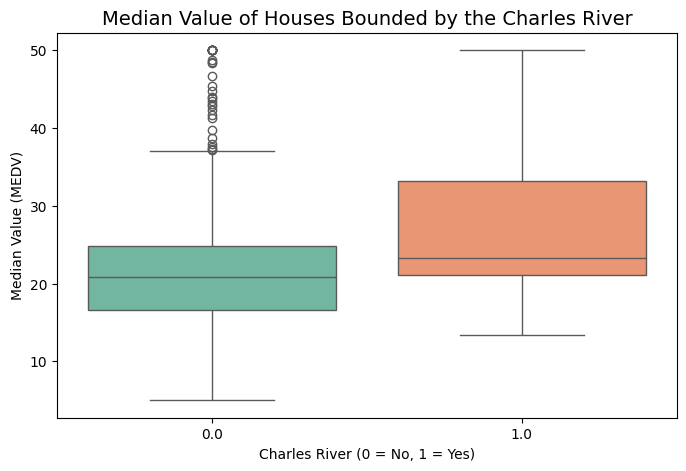

In [20]:
# Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='CHAS', y='MEDV', data=boston_df, hue='CHAS', palette='Set2', legend=False)
plt.title('Median Value of Houses Bounded by the Charles River', fontsize=14)
plt.xlabel('Charles River (0 = No, 1 = Yes)')
plt.ylabel('Median Value (MEDV)')
plt.show()

**H0:**
  The median value of houses bounded by the Charles River and not bounded by the river is the same.

**H1:**
  There is a difference in median value of houses bounded by Charles River and not bounded by the river.

**Conduct a T-Test**

In [21]:
# Conduct T-test
t_static, p_val = stats.ttest_ind(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                                boston_df[boston_df['CHAS'] == 1]['MEDV'],
                                equal_var = False)

print(f"T-Statistic: {t_static:.4f}")
print(f"P-Value: {p_val:.4f}")

T-Statistic: -3.1133
P-Value: 0.0036


**Interpretation :**

 > Since the **p-value (0.0036)** is less than the significance level of **0.05**, we **reject the Null Hypothesis**. There is strong statistical evidence to conclude that there is a significant difference in the median value of houses (MEDV) between those bounded by the Charles River and those that are not. Even after accounting for unequal variances, the river proximity remains a significant factor in housing prices

**Question #2 : Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)?**

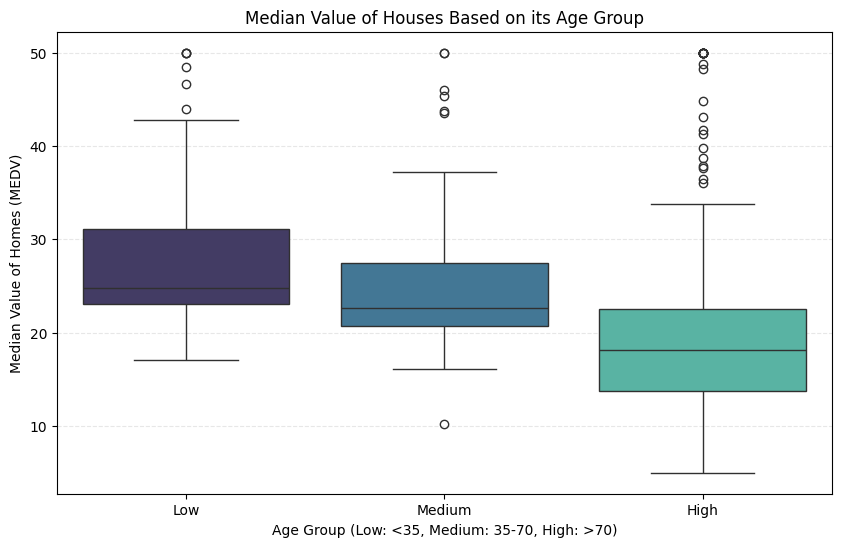

In [22]:
# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df,
            hue='AGE_GROUP', palette='mako', legend=False)

# Labels
plt.title('Median Value of Houses Based on its Age Group')
plt.xlabel('Age Group (Low: <35, Medium: 35-70, High: >70)')
plt.ylabel('Median Value of Homes (MEDV)')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

**H0:**
  There is no difference in median values of houses for each proportion of owner occupied units built prior to 1940.

**H1:**
  There is a difference in median values of houses for each proportion of owner occupied units built prior to 1940.

**Test for equality of variance**

In [23]:
# Create groups
low = boston_df[boston_df['AGE_GROUP'] == 'Low']['MEDV']
medium = boston_df[boston_df['AGE_GROUP'] == 'Medium']['MEDV']
high = boston_df[boston_df['AGE_GROUP'] == 'High']['MEDV']

# Perform ANOVA test
stat_result, p_result = stats.f_oneway(low, medium, high)

print("F-statistic:", stat_result)
print("P-value:", p_result)

F-statistic: 36.40764999196598
P-value: 1.7105011022702984e-15


**Interpretation :**

> Since the p-value ($1.71 \times 10^{-15}$) is significantly less than the alpha level of $0.05$, we **reject the Null Hypothesis**. There is strong statistical evidence to conclude that the median value of houses (MEDV) differs significantly across the three age groups (Low, Medium, and High).

**Question #3 : Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town?**

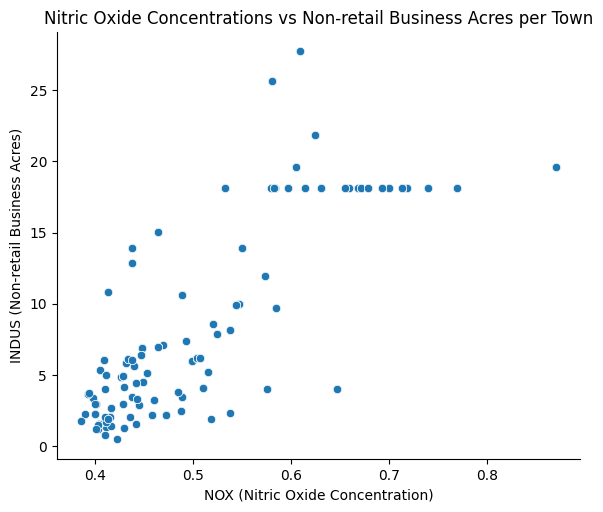

In [24]:
# Regression Plot
sns.relplot(x='NOX', y='INDUS', data=boston_df, height=5, aspect=1.2)

plt.title('Nitric Oxide Concentrations vs Non-retail Business Acres per Town')
plt.xlabel('NOX (Nitric Oxide Concentration)')
plt.ylabel('INDUS (Non-retail Business Acres)')

plt.show()

**H0:**
  There is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town.

**H1:**
 There is a relationship between Nitric oxide concentrations and proportion of non-retail business acres per town

**Conduct a pearson correlation test**

In [25]:
# Conduct a pearson correlation test
correlation_coeff, p_result_val = stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

print("Pearson Correlation Results\n")
print(f"Correlation Coefficient: {correlation_coeff:.4f}")
print(f"P-value                : {p_result_val:.4e}") # Scientific notation சிறந்தது

Pearson Correlation Results

Correlation Coefficient: 0.7637
P-value                : 7.9134e-98



**Interpretation :**

> Since the **Correlation Coefficient** ($r$) is $0.7637$, there is a **strong positive relationship** between Nitric Oxide concentrations (NOX) and the proportion of non-retail business acres (INDUS). The extremely low p-value ($7.91 \times 10^{-98}$) indicates that we can **reject the Null Hypothesis**. This means that towns with a higher proportion of non-retail business acres tend to have significantly higher nitric oxide concentrations.

**Question #4: What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes?**

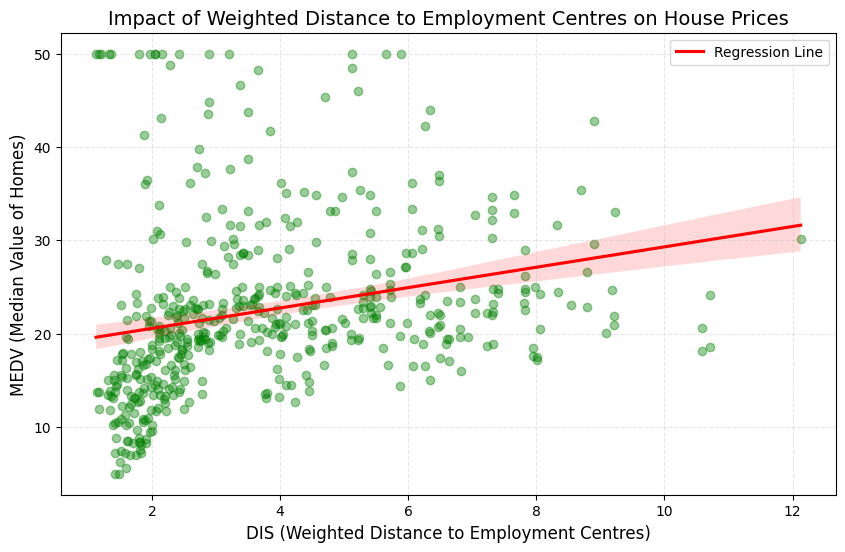

In [26]:
# REgression plot
plt.figure(figsize=(10, 6))

sns.regplot(x='DIS', y='MEDV', data=boston_df,
            line_kws={"color": "red", "label": "Regression Line"},
            scatter_kws={"alpha": 0.4, "color": "green"})

plt.title('Impact of Weighted Distance to Employment Centres on House Prices', fontsize=14)
plt.xlabel('DIS (Weighted Distance to Employment Centres)', fontsize=12)
plt.ylabel('MEDV (Median Value of Homes)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

**H0:**
  There is no impact of an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes.

**H1:**
  There is an impact of an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes.

**Coduct Pearson Correlation Test**

In [27]:
# Coduct Pearson Correlation Test
# X and y eatures
X = boston_df['DIS']
y = boston_df['MEDV']
X = sm.add_constant(X) # Intercept

# Create model
model = sm.OLS(y, X).fit()

# Prediction
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.21e-08
Time:                        04:44:18   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

**Interpretation :**

>The regression analysis reveals a statistically significant positive impact of distance (DIS) on home values (MEDV), with a **p-value** of **0.000**. The co**efficient** of 1.0916 suggests that for every additional unit of distance to employment centres, the median home value increases by approximately $1,091. The regression line in the plot clearly shows this upward trend, though the low R**-squared** (0.062) indicates that distance is only one of many factors influencing the price.
**Reject null hypothesis**(Distance has a significant positive impact on price).